In [1]:
import pandas as pd
from scipy.stats import skew, kurtosis
from scipy.signal import welch
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt
from scipy.signal import spectrogram
from scipy.ndimage import gaussian_filter1d
from scipy.signal import convolve
from scipy.signal import find_peaks
import random
from scipy.signal import savgol_filter

In [2]:
CONTEXT = 10

class Pipeline:

    d = None
    d_left = None
    
    x_diff = None
    y_diff = None

    x_mask = None
    y_mask = None
    mask= None

    saccade_signals = None
    saccade_gen = None
    saccade_seq = None
    
    
    def __init__(self, t, x, y, x_left, y_left):
        self.t = t
        self.x = x
        self.y = y
        self.x_left = x_left
        self.y_left = y_left

    def run(self):
        
        (
        self.t,
        self.x,
        self.y,
        self.x_left,
        self.y_left
        ) = self.__drop_nans_with_context(self.t, self.x, self.y, self.x_left, self.y_left, context_size=5)
        
        self.t = self.__normalization_min_max_positive(self.t)
        self.x = self.__normalization_min_max(self.x)
        self.y = self.__normalization_min_max(self.y)
        self.x_left = self.__normalization_min_max(self.x_left)
        self.y_left = self.__normalization_min_max(self.y_left)

        self.d = self.__calculate_distance(self.x, self.y)
        self.d_left = self.__calculate_distance(self.x_left, self.y_left)
        
        self.__calculate_diff()
        
        self.x_diff = self.__normalization_min_max_positive(self.x_diff)
        self.y_diff = self.__normalization_min_max_positive(self.y_diff)
        
        self.x_diff = self.__strech_signal(self.x_diff)
        self.y_diff = self.__strech_signal(self.y_diff)
        
        self.x_diff = self.__highpass_filtering(self.x_diff)
        self.y_diff = self.__highpass_filtering(self.y_diff)
        
        self.x_diff = self.__normalization_min_max_positive(self.x_diff)
        self.y_diff = self.__normalization_min_max_positive(self.y_diff)
        
        self.x_diff = self.__smooth_signal(self.x_diff)
        self.y_diff = self.__smooth_signal(self.y_diff)

        self.x_diff = self.__highligth_peaks(self.x_diff)
        self.y_diff = self.__highligth_peaks(self.y_diff)

        self.x_diff = abs(self.x_diff)
        self.y_diff = abs(self.y_diff)

        self.x_diff = self.__lowpass_filtering(self.x_diff)
        self.y_diff = self.__lowpass_filtering(self.y_diff)
        
        self.x_diff = abs(self.x_diff)
        self.y_diff = abs(self.y_diff)

        self.x_diff = self.__zero_outliers(self.x_diff)
        self.y_diff = self.__zero_outliers(self.y_diff)

        self.x_diff = self.__normalization_min_max_positive(self.x_diff)
        self.y_diff = self.__normalization_min_max_positive(self.y_diff)

        self.x_diff = self.__strech_signal(self.x_diff)
        self.y_diff = self.__strech_signal(self.y_diff)

        self.x_diff = self.__normalization_min_max_positive(self.x_diff)
        self.y_diff = self.__normalization_min_max_positive(self.y_diff)

        self.x_mask = self.__detect_peaks(self.x_diff, prominence=0.05, distance=10)
        self.y_mask = self.__detect_peaks(self.y_diff, prominence=0.05, distance=10)

        # self.__plot_results()

        self.d = self.__normalization_min_max_positive(self.d)
        self.d_left = self.__normalization_min_max_positive(self.d_left)
        
        self.mask = self.__contextual_dot_product(self.x_mask, self.y_mask, context=10)

        self.x = self.__normalization_min_max_positive(self.x)
        self.y = self.__normalization_min_max_positive(self.y)
        self.x_left = self.__normalization_min_max_positive(self.x_left)
        self.y_left = self.__normalization_min_max_positive(self.y_left)
        
        x_saccade = self.__extract_peak_segments(self.x, self.mask, context_size=CONTEXT)
        y_saccade = self.__extract_peak_segments(self.y, self.mask, context_size=CONTEXT)
        x_left_saccade = self.__extract_peak_segments(self.x_left, self.mask, context_size=CONTEXT)
        y_left_saccade = self.__extract_peak_segments(self.y_left, self.mask, context_size=CONTEXT)
        d_saccade = self.__extract_peak_segments(self.d, self.mask, context_size=CONTEXT)
        d_left_saccade = self.__extract_peak_segments(self.d_left, self.mask, context_size=CONTEXT)

        y_saccade = self.__normalize_fragments(y_saccade)
        
        return y_saccade, y_saccade, y_saccade, y_saccade, y_saccade, y_saccade, 

    def __drop_nans_with_context(self, *signals, context_size=10):
        assert len(signals) > 0, "At least one signal must be provided."
    
        signals = [pd.Series(sig).reset_index(drop=True) if not isinstance(sig, pd.Series) else sig.reset_index(drop=True) for sig in signals]
        nan_indices = np.unique(np.concatenate([
            sig[sig.isna() | (sig == "nan")].index for sig in signals
        ]))
    
        if len(nan_indices) == 0:
            return signals

        expanded_indices = np.unique(np.concatenate([
            np.arange(max(0, idx - context_size), min(len(signals[0]), idx + context_size + 1))
            for idx in nan_indices
        ]))
    
        filtered_signals = [sig.drop(expanded_indices).reset_index(drop=True) for sig in signals]
    
        filtered_signals = [sig.dropna().reset_index(drop=True) for sig in filtered_signals]
    
        min_length = min(map(len, filtered_signals))
        filtered_signals = [sig.iloc[:min_length].reset_index(drop=True) for sig in filtered_signals]
    
        return tuple(filtered_signals)

    def __calculate_distance(self, x, y):
        return np.sqrt(np.power(x, 2) + np.power(y, 2))
        
    def __calculate_diff(self):
        self.x_diff = abs(self.x - self.x_left)
        self.y_diff = abs(self.y - self.y_left)

    def __normalization_min_max_positive(self, signal):
        return (signal - signal.min()) / (signal.max() - signal.min())

    def __normalization_min_max(self, signal):
        return 2*((signal - signal.min()) / (signal.max() - signal.min())) - 1

    def __strech_signal(self, signal):
        power = 2
        mean = signal.mean()
        
        signal = np.power(signal, power)
        signal = signal / signal.mean() * mean

        return signal

    def __highpass_filtering(self, signal):
        def highpass_filter(data, cutoff=len(self.t) / 1e1, fs=1/np.mean(np.diff(self.t)), order=4):
            nyquist = 0.5 * fs  # Nyquist frequency
            normal_cutoff = cutoff / nyquist  # Normalize cutoff frequency
            b, a = butter(order, normal_cutoff, btype='high', analog=False)  # Change to 'high'
            return filtfilt(b, a, data)

        return highpass_filter(signal)

    def __smooth_signal(self, signal, sigma=5):
        return gaussian_filter1d(signal, sigma=sigma)

    def __highligth_peaks(self,signal):
        difference_kernel = np.array([-1,-1, 0, 1,1]) 
        return convolve(signal, difference_kernel, mode="same")

    def __lowpass_filtering(self, signal):
        def lowpass_filter(data, cutoff=len(self.t) / 1e1, fs=1/np.mean(np.diff(self.t)), order=4):
            nyquist = 0.5 * fs  # Nyquist frequency
            normal_cutoff = cutoff / nyquist  # Normalize cutoff frequency
            b, a = butter(order, normal_cutoff, btype='low', analog=False)
            return filtfilt(b, a, data)

        return lowpass_filter(signal)

    def __zero_outliers(self, signal):
        Q1 = np.percentile(signal, 5) 
        Q3 = np.percentile(signal, 95)
        IQR = Q3 - Q1
        
        lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
        filtered_signal = signal.copy()
        filtered_signal[(filtered_signal < lower) | (filtered_signal > upper)] = 0
    
        return filtered_signal

    def __detect_peaks(self, signal, height=None, prominence=0.1, distance=5):
        signal = np.array(signal)
        peaks, _ = find_peaks(signal, height=height, prominence=prominence, distance=distance)
        peak_mask = np.zeros(len(signal), dtype=int)
        peak_mask[peaks] = 1
        
        return peak_mask

    def __plot_results(self):

        start = 32498
        end = start + 200
        
        fig, axes = plt.subplots(6, 1, figsize=(8, 8), sharex=True)
        
        axes[0].plot(self.t.iloc[start:end], self.x.iloc[start:end], marker='o', linestyle='-', markersize=2, alpha=0.7)
        axes[0].set_ylabel("X Position Rigth Eye")
        axes[0].set_title("X vs Time")
        axes[0].grid(True)
        
        axes[1].plot(self.t.iloc[start:end], self.x_left.iloc[start:end], marker='o', linestyle='-', markersize=2, alpha=0.7)
        axes[1].set_xlabel("Time (Normalized)")
        axes[1].set_ylabel("X Position Left Eye")
        axes[1].set_title("X vs Time")
        axes[1].grid(True)
        
        axes[2].plot(self.t.iloc[start:end], self.x_mask[start:end], marker='o', linestyle='-', markersize=2, alpha=0.7)
        axes[2].set_xlabel("Time (Normalized)")
        axes[2].set_ylabel("X Diffrence")
        axes[2].set_title("saccade movement")
        axes[2].grid(True)

        axes[3].plot(self.t.iloc[start:end], self.y.iloc[start:end], marker='o', linestyle='-', markersize=2, alpha=0.7)
        axes[3].set_ylabel("X Position Rigth Eye")
        axes[3].set_title("Y vs Time")
        axes[3].grid(True)
        
        axes[4].plot(self.t.iloc[start:end], self.y_left.iloc[start:end], marker='o', linestyle='-', markersize=2, alpha=0.7)
        axes[4].set_xlabel("Time (Normalized)")
        axes[4].set_ylabel("X Position Left Eye")
        axes[4].set_title("Y vs Time")
        axes[4].grid(True)
        
        axes[5].plot(self.t.iloc[start:end], self.y_mask[start:end], marker='o', linestyle='-', markersize=2, alpha=0.7)
        axes[5].set_xlabel("Time (Normalized)")
        axes[5].set_ylabel("X Diffrence")
        axes[5].set_title("saccade movement")
        axes[5].grid(True)
        
        plt.tight_layout()
        plt.show()

    def __extract_peak_segments(self, signal, mask, context_size=5):
        signal = np.array(signal)
        mask = np.array(mask)
    
        assert len(signal) == len(mask), "Signal and mask must have the same length."
    
        extracted_segments = []
        peak_indices = np.where(mask == 1)[0]
    
        for idx in peak_indices:
            start = max(0, idx - context_size)
            end = min(len(signal), idx + context_size + 1)
            
            extracted_segments.append(signal[start:end])
        return extracted_segments

    def __generate_smoothed_signal(self, fragments):
        if not fragments:
            return
        random.shuffle(fragments)
        smoothed_signal = [fragments[0]]
    
        last_value = fragments[0][-1]
    
        for i in range(1, len(fragments)):
            shift = last_value - fragments[i][0]
            translated_fragment = fragments[i] + shift
    
            smoothed_signal.append(translated_fragment)
            last_value = translated_fragment[-1]

        yield np.concatenate(smoothed_signal)

    def __savgol_filter(self, signal):
        return savgol_filter(signal, window_length=11, polyorder=3)
    
    def __idt(self, x, y, t, velocity_threshold=30):
        dx = np.diff(x)
        dy = np.diff(y)
        dt = np.diff(t)
    
        velocity = np.sqrt(dx**2 + dy**2) / dt  
        velocity = np.insert(velocity, 0, 0)
    
        saccade_mask = velocity > velocity_threshold
        saccade_mask = saccade_mask.astype(int)
    
        return saccade_mask
    
    def __contextual_dot_product(self, signal1, signal2, context):
        assert len(signal1) == len(signal2), "Signals must be of equal length"
    
        # Create a kernel with ones in the given context range
        kernel = np.ones(2 * context + 1)
    
        # Convolve signal2 with the kernel (this spreads 1s over the context)
        spread_signal2 = convolve(signal2, kernel, mode='same')  # 'same' keeps original size
    
        # Convert convolved signal to binary (any nonzero value means a 1 was nearby)
        spread_signal2 = (spread_signal2 > 0).astype(int)
    
        # Perform element-wise AND (dot product-like)
        result = signal1 * spread_signal2
        return result

    def __normalize_fragments(self, arrays):
        normalized_arrays = []
        for arr in arrays:
            arr_min = np.min(arr)
            arr_max = np.max(arr)
            if arr_max == arr_min:
                normalized_arrays.append(np.zeros_like(arr))  # Avoid division by zero, return zeros
            else:
                normalized_arrays.append((arr - arr_min) / (arr_max - arr_min))
        return normalized_arrays




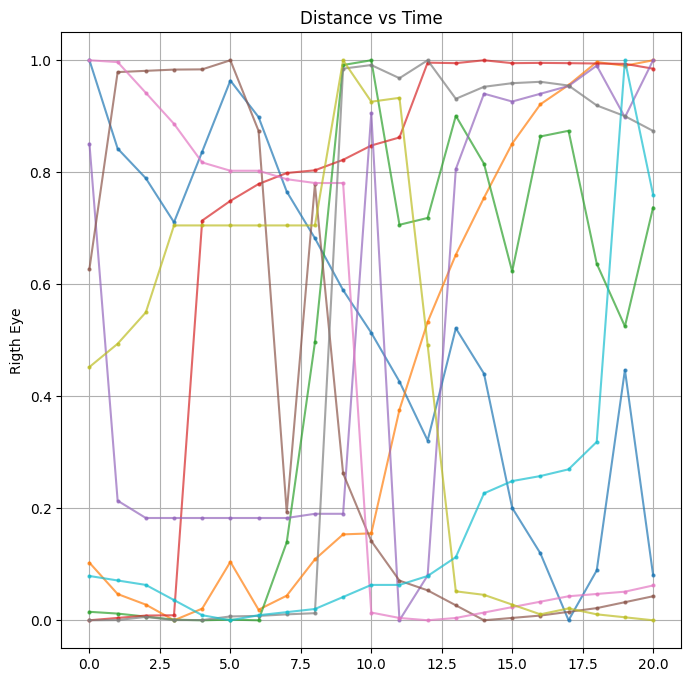

In [3]:
file_path = "../data/00/data.csv"
df = pd.read_csv(file_path)

selected_columns = ["t", "right_gaze_origin_position_in_hmd_coordinates_x", "right_gaze_origin_position_in_hmd_coordinates_y",
                    "left_gaze_origin_position_in_hmd_coordinates_x", "left_gaze_origin_position_in_hmd_coordinates_y"]
df = df[selected_columns]

df = df.rename(columns={
    "right_gaze_origin_position_in_hmd_coordinates_x": "x",
    "right_gaze_origin_position_in_hmd_coordinates_y": "y",
    "left_gaze_origin_position_in_hmd_coordinates_x": "x_left",
    "left_gaze_origin_position_in_hmd_coordinates_y": "y_left"
})

pipeline = Pipeline(df["t"], df["x"], df["y"], df["x_left"], df["y_left"])
saccade_signals = pipeline.run()

num_features = len(saccade_signals)

fig, axes = plt.subplots(1, 1, figsize=(8, 8), sharex=True)

for signal in saccade_signals[3][:10]:
    axes.plot(signal, marker='o', linestyle='-', markersize=2, alpha=0.7)
axes.set_ylabel("Rigth Eye")
axes.set_title("Distance vs Time")
axes.grid(True)

# print(len(saccade_seq))

In [4]:
labels = [i for i in range(10)] # 9, 11 [0, 1, 9, 5] -> 62%(66% dla random forest)(80% przy CONTEXT = 100) [51, 7] -> 60%
labels_num = len(labels)

In [5]:
num_signals = 5

In [6]:
import pandas as pd

# Selected columns to read from each CSV file
selected_columns = [
    "t", "right_gaze_origin_position_in_hmd_coordinates_x", "right_gaze_origin_position_in_hmd_coordinates_y",
    "left_gaze_origin_position_in_hmd_coordinates_x", "left_gaze_origin_position_in_hmd_coordinates_y"
]

# Renaming dictionary (base names)
rename_dict = {
    "t": "t", 
    "right_gaze_origin_position_in_hmd_coordinates_x": "x",
    "right_gaze_origin_position_in_hmd_coordinates_y": "y",
    "left_gaze_origin_position_in_hmd_coordinates_x": "x_left",
    "left_gaze_origin_position_in_hmd_coordinates_y": "y_left"
}

# List to store all DataFrames
df_list = []

# Load each CSV file and process it
for i in labels:  # Loop from 00 to 09
    file_path = f"../data/{i:02d}/data.csv"  # Format path dynamically
    
    # Load CSV, only select needed columns
    df = pd.read_csv(file_path, usecols=selected_columns)
    
    # Trim to 100,000 rows
    df = df.iloc[:100000]
    
    # Rename columns with appropriate suffix
    df = df.rename(columns={col: f"{rename_dict[col]}{i:02d}" for col in selected_columns})
    
    # Append processed DataFrame to the list
    df_list.append(df)

# Concatenate all DataFrames side-by-side
merged_df = pd.concat(df_list, axis=1)

merged_df.head()


,t00,x00,y00,x_left00,y_left00,t01,x01,y01,x_left01,y_left01,...,t08,x08,y08,x_left08,y_left08,t09,x09,y09,x_left09,y_left09
0,1.581362e+15,-29.585846,1.740021,32.436142,5.695251,1.583335e+15,-33.649307,0.915329,29.914169,4.788696,...,1.583765e+15,-33.262161,5.119858,29.977646,6.512436,1.580230e+15,-28.541779,-3.547134,30.893646,0.299438
1,1.581362e+15,-29.591797,1.740555,32.421951,5.614624,1.583335e+15,-33.651520,0.925964,29.914185,4.745239,...,1.583765e+15,-33.262024,5.121719,29.980591,6.509903,1.580230e+15,-28.522461,-3.565674,30.923523,0.318237
2,1.581362e+15,-29.599228,1.711990,32.406448,5.580765,1.583335e+15,-33.654449,0.910370,29.913483,4.757553,...,1.583765e+15,-33.256668,5.013565,29.983536,6.507385,1.580230e+15,-28.507446,-3.568237,30.949448,0.334656
3,1.581362e+15,-29.606445,1.710693,32.386810,5.647583,1.583335e+15,-33.655487,0.906570,29.913757,4.726425,...,1.583765e+15,-33.253677,5.046753,29.986649,6.505325,1.580230e+15,-28.499115,-3.509537,30.971619,0.312561
4,1.581362e+15,-29.615341,1.769791,32.370270,5.730347,1.583335e+15,-33.656067,0.902786,29.921448,4.677521,...,1.583765e+15,-33.253036,5.035599,29.989761,6.507141,1.580230e+15,-28.491806,-3.493378,30.991745,0.285873


In [7]:
import pandas as pd
import numpy as np

# List of signal types to extract
signal_types = ["t", "x", "y", "x_left", "y_left"]

# Create an empty list to store instances
instances = []

_, labels_norm = np.unique(labels, return_inverse=True)
# Iterate over the 10 labels (00 to 09)
for i, label in zip(labels, labels_norm):  
    
    for signal_type in signal_types:  # Iterate over all signal types
        signal = merged_df[f"{signal_type}{i:02d}"]  # Extract the correct column
        
        # Split the signal into 10 segments of 10,000 each
        for j in range(10):
            segment = signal[j * 10000 : (j + 1) * 10000].values  # Extract 10,000-length segment
            
            # Create a row with label, signal type, segment number, and signal values
            instance = [label, signal_type, j + 1] + list(segment)  # j+1 to start segments from 1
            
            # Store instance
            instances.append(instance)

# Define column names
columns = ["label", "signal_type", "segment"] + [f"dim_{i}" for i in range(10000)]

# Convert list to DataFrame
df_processed = pd.DataFrame(instances, columns=columns)

df_processed.head()

,label,signal_type,segment,dim_0,dim_1,dim_2,dim_3,dim_4,dim_5,dim_6,...,dim_9990,dim_9991,dim_9992,dim_9993,dim_9994,dim_9995,dim_9996,dim_9997,dim_9998,dim_9999
0,0,t,1,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,...,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15
1,0,t,2,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,...,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15
2,0,t,3,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,...,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15
3,0,t,4,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,...,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15
4,0,t,5,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,...,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15


In [8]:
df_train_raw = df_processed[df_processed["segment"].between(1, 6)]
df_val_raw = df_processed[df_processed["segment"].between(7,8)]
df_test_raw = df_processed[df_processed["segment"].between(9,10)]

In [9]:
df_train_raw.head()

,label,signal_type,segment,dim_0,dim_1,dim_2,dim_3,dim_4,dim_5,dim_6,...,dim_9990,dim_9991,dim_9992,dim_9993,dim_9994,dim_9995,dim_9996,dim_9997,dim_9998,dim_9999
0,0,t,1,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,...,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15
1,0,t,2,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,...,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15
2,0,t,3,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,...,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15
3,0,t,4,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,...,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15
4,0,t,5,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,...,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15


In [10]:
df_test_raw.head()

,label,signal_type,segment,dim_0,dim_1,dim_2,dim_3,dim_4,dim_5,dim_6,...,dim_9990,dim_9991,dim_9992,dim_9993,dim_9994,dim_9995,dim_9996,dim_9997,dim_9998,dim_9999
8,0,t,9,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,...,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15
9,0,t,10,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,...,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15
18,0,x,9,-2.990927e+01,-2.998026e+01,-3.002446e+01,-3.001945e+01,-3.001668e+01,-3.001811e+01,-3.003775e+01,...,-3.049767e+01,-3.049767e+01,-3.049767e+01,-3.049771e+01,-3.049779e+01,-3.049789e+01,-3.048491e+01,-3.037790e+01,-3.016847e+01,-2.997070e+01
19,0,x,10,-2.991096e+01,-2.991100e+01,-2.993440e+01,-2.994386e+01,-2.993948e+01,-2.993697e+01,-2.993445e+01,...,-3.110291e+01,-3.115651e+01,-3.117418e+01,-3.118117e+01,-3.120784e+01,-3.121338e+01,-3.121408e+01,-3.121478e+01,-3.121684e+01,-3.121889e+01
28,0,y,9,4.440231e+00,4.467010e+00,4.447861e+00,4.524704e+00,4.523743e+00,4.494003e+00,4.359497e+00,...,3.703949e+00,3.703949e+00,3.703949e+00,3.702026e+00,3.701538e+00,3.701096e+00,3.720657e+00,3.821564e+00,3.790878e+00,3.927002e+00


In [11]:
df_val_raw.head()

,label,signal_type,segment,dim_0,dim_1,dim_2,dim_3,dim_4,dim_5,dim_6,...,dim_9990,dim_9991,dim_9992,dim_9993,dim_9994,dim_9995,dim_9996,dim_9997,dim_9998,dim_9999
6,0,t,7,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,...,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15
7,0,t,8,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,...,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15,1.581362e+15
16,0,x,7,-2.964194e+01,-2.963448e+01,-2.966989e+01,-2.967346e+01,-2.967860e+01,-2.967662e+01,-2.967274e+01,...,-2.988069e+01,-2.988994e+01,-2.988834e+01,-2.988745e+01,-2.988666e+01,-2.988661e+01,-2.988655e+01,-2.988615e+01,-2.988655e+01,-2.988634e+01
17,0,x,8,-2.988655e+01,-2.988634e+01,-2.988655e+01,-2.988661e+01,-2.988666e+01,-2.988678e+01,-2.988690e+01,...,-2.988496e+01,-2.988054e+01,-2.987500e+01,-2.988220e+01,-2.986838e+01,-2.987280e+01,-2.985788e+01,-2.986806e+01,-2.986948e+01,-2.987563e+01
26,0,y,7,4.521317e+00,4.422272e+00,4.166809e+00,4.100616e+00,4.008209e+00,4.072952e+00,4.102341e+00,...,3.152298e+00,3.182236e+00,3.212982e+00,3.208160e+00,3.212982e+00,3.213165e+00,3.213364e+00,3.213715e+00,3.214081e+00,3.214233e+00


# features generation

In [12]:
def generate_features(df):
    generated_signals = []
    generated_labels = []
    generated_subsequences = []
    i = 0
    # Iterate over unique labels
    for label in df["label"].unique():
        df_label = df[df["label"] == label]
    
        # Iterate over unique segments
        for segment in df_label["segment"].unique():
            df_segment = df_label[df_label["segment"] == segment]
    
            # Extract input signals for the pipeline based on signal_type
            t = df_segment[df_segment["signal_type"] == "t"].drop(columns=["label", "signal_type", "segment"]).values.flatten()
            x = df_segment[df_segment["signal_type"] == "x"].drop(columns=["label", "signal_type", "segment"]).values.flatten()
            y = df_segment[df_segment["signal_type"] == "y"].drop(columns=["label", "signal_type", "segment"]).values.flatten()
            x_left = df_segment[df_segment["signal_type"] == "x_left"].drop(columns=["label", "signal_type", "segment"]).values.flatten()
            y_left = df_segment[df_segment["signal_type"] == "y_left"].drop(columns=["label", "signal_type", "segment"]).values.flatten()
    
            # Run the pipeline 10 times for each segment
            # for _ in range(10):
            pipeline = Pipeline(t, x, y, x_left, y_left)
            results = pipeline.run()

            # print(f'reults len: {len(results)}')
            assert len(results) == num_features, 'len of resutls is diffrent than 6'
            result_shape = len(results[0])
            for result in results:
                for signal in result:
                    # print(len(signal))
                    # assert len(signal) == 2 * CONTEXT + 1, 'len of signal is inconcisent'
                    assert len(result) == result_shape, 'result shape is inconsitent'
                    # print(f'result shape ({len(result)},{len(signal)})')
            
            # Store the generated signal and label
            for result in results:
                valid_result = [signal for signal in result if len(signal) == 2 * CONTEXT + 1]
                # print(valid_result)
                generated_signals.extend(valid_result)
                generated_labels.extend([label]*len(valid_result))
                # generated_labels.append(label)
                generated_subsequences.extend([i]*len(valid_result))
            i += 1

    # generated_signals = np.vstack(generated_signals)
    # Convert results into DataFrame
    print(len(generated_signals))
    return pd.DataFrame(generated_signals), pd.DataFrame({"label": generated_labels}), pd.DataFrame(generated_subsequences)

df_train, df_train_labels, df_train_subsequnces = generate_features(df_train_raw)
# df_train = df_train.iloc[:, :1000]

df_test, df_test_labels, df_test_subsequnces = generate_features(df_test_raw)
# df_test = df_test.iloc[:, :1000]

df_val, df_val_labels, df_val_subsequnces = generate_features(df_val_raw)
# df_val = df_val.iloc[:, :1000]

8988
2460
2526


## Deep Learning

In [13]:
import torch
import numpy as np
import random

def set_seed(seed=0):
    torch.manual_seed(seed)  # Sets PyTorch seed (CPU)
    torch.cuda.manual_seed(seed)  # Sets PyTorch seed (GPU)
    torch.cuda.manual_seed_all(seed)  # If using multi-GPU
    np.random.seed(seed)  # Sets NumPy seed
    random.seed(seed)  # Sets Python random seed

    torch.backends.cudnn.deterministic = True  # Ensures deterministic behavior
    torch.backends.cudnn.benchmark = False  # Disables cuDNN optimization for reproducibility

set_seed(0)  # Set seed to 0

In [14]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import numpy as np

from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

In [15]:
import numpy as np
import torch
import pandas as pd

# Define constants
NUM_SIGNALS = num_signals  # Number of signals per segment (e.g., t, x, y, x_left, y_left)
NUM_FEATURES = num_features  # Number of features per signal (e.g., raw, velocity, acceleration)
SEQUENCE_LENGTH = df_train.shape[1]  # Assuming this is 201

def reshape_data(df_signals, df_labels, df_subsequences):
    """
    Transforms data into shape (num_samples, num_features, num_signals, sequence_length)
    by grouping signals that originated from the same segment.
    """
    # Convert DataFrame to numpy
    X = df_signals.values  # Shape: (total_samples, sequence_length)
    y = df_labels.values.flatten()  # Shape: (total_samples,)
    subseq = df_subsequences.values.flatten()  # Shape: (total_samples,)

    # Store results
    X_train_list, y_train_list = [], []

    # Group by unique segments
    unique_segments = np.unique(subseq)

    for segment in unique_segments:
        # Get indices for the current segment
        segment_indices = np.where(subseq == segment)[0]

        # Extract data for the segment
        X_segment = X[segment_indices]  # Shape: (num_samples_in_segment, sequence_length)
        y_segment = y[segment_indices]  # Shape: (num_samples_in_segment,)

        # Ensure we have at least NUM_SIGNALS samples
        if len(segment_indices) < NUM_SIGNALS:
            continue  # Skip segments with too few samples

        num_samples_in_segment = X_segment.shape[0]

        # Trim `X_segment` to be divisible by `NUM_SIGNALS`
        num_samples_trimmed = (num_samples_in_segment // NUM_SIGNALS) * NUM_SIGNALS
        if num_samples_trimmed == 0:
            continue  # Skip if not enough samples after trimming

        X_segment = X_segment[:num_samples_trimmed]  # Trim to the nearest multiple of NUM_SIGNALS
        y_segment = y_segment[:num_samples_trimmed]  # Trim labels accordingly

        # Compute the number of groups
        num_groups = num_samples_trimmed // NUM_SIGNALS

        # **Fix: Verify actual and expected size before reshaping**
        actual_elements = X_segment.size
        expected_elements = num_groups * NUM_SIGNALS * SEQUENCE_LENGTH
        if actual_elements != expected_elements:
            print(f"Skipping segment {segment} due to size mismatch: expected {expected_elements}, got {actual_elements}")
            continue

        # Reshape into (num_groups, num_signals, sequence_length)
        X_segment = X_segment.reshape(num_groups, NUM_SIGNALS, SEQUENCE_LENGTH)

        # **Fix: Add features as a new dimension**
        X_segment = np.expand_dims(X_segment, axis=2)  # Shape: (num_groups, num_signals, 1, sequence_length)
        X_segment = np.repeat(X_segment, NUM_FEATURES, axis=2)  # Expand to (num_groups, num_signals, num_features, sequence_length)

        # Transpose to match CNN input format: (num_samples, num_features, num_signals, sequence_length)
        X_segment = np.transpose(X_segment, (0, 2, 1, 3))  # (num_samples, num_features, num_signals, sequence_length)

        # Append to dataset
        X_train_list.append(X_segment)
        y_train_list.append(y_segment[::NUM_SIGNALS])  # Take one label per group

    # Convert to numpy arrays
    if len(X_train_list) == 0:
        print("⚠ Warning: No valid segments found! Returning empty arrays.")
        return np.array([]), np.array([])  # Return empty arrays if no valid segments were found

    X_train = np.concatenate(X_train_list, axis=0)  # Shape: (num_samples, num_features, num_signals, sequence_length)
    y_train = np.concatenate(y_train_list, axis=0)  # Shape: (num_samples,)

    return X_train, y_train

# Reshape training data
X_train, y_train = reshape_data(df_train, df_train_labels, df_train_subsequnces)
X_test, y_test = reshape_data(df_test, df_test_labels, df_test_subsequnces)
X_val, y_val = reshape_data(df_val, df_val_labels, df_val_subsequnces)

# Print final shape
print(f"✅ X_train shape: {X_train.shape}")  # Expected: (num_samples, num_features, num_signals, sequence_length)
print(f"✅ y_train shape: {y_train.shape}")  # Expected: (num_samples,)

# Convert to PyTorch tensors
if X_train.size > 0:
    X_train = torch.tensor(X_train, dtype=torch.float32)  # Convert to float32
    y_train = torch.tensor(y_train, dtype=torch.long)  # Labels should be long for CrossEntropyLoss

    train_dataset = torch.utils.data.TensorDataset(X_train, y_train)
    train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=16, shuffle=True)

if X_test.size > 0:
    X_test = torch.tensor(X_test, dtype=torch.float32)  # Convert to float32
    y_test = torch.tensor(y_test, dtype=torch.long)  # Labels should be long for CrossEntropyLoss

    test_dataset = torch.utils.data.TensorDataset(X_test, y_test)
    test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=16, shuffle=False)

if X_val.size > 0:
    X_val = torch.tensor(X_val, dtype=torch.float32)  # Convert to float32
    y_val = torch.tensor(y_val, dtype=torch.long)  # Labels should be long for CrossEntropyLoss

    val_dataset = torch.utils.data.TensorDataset(X_val, y_val)
    val_loader = torch.utils.data.DataLoader(val_dataset, batch_size=16, shuffle=False)


✅ X_train shape: (1775, 6, 5, 21)
✅ y_train shape: (1775,)


In [19]:
class NN(nn.Module):
    def __init__(self, num_classes):
        super(NN, self).__init__()

        neurons = np.array([4, 8, 16, 32]) * 64
        
        # First Conv2D Layer: Input (num_features, num_signals, sequence_length)
        self.conv1 = nn.Conv2d(in_channels=num_signals, out_channels=neurons[0], kernel_size=(4, 8), stride=1, padding=1) # 32
        self.bn1 = nn.BatchNorm2d(neurons[0])

        # Second Conv2D Layer
        self.conv2 = nn.Conv2d(neurons[0], neurons[1], kernel_size=(2, 4), stride=1, padding=1) # 16
        self.bn2 = nn.BatchNorm2d(neurons[1])

        # Third Conv2D Layer
        self.conv3 = nn.Conv2d(neurons[1], neurons[2], kernel_size=(1, 2), stride=1, padding=1) # 8
        self.bn3 = nn.BatchNorm2d(neurons[2])

        # Pooling and Dropout Layers1
        self.pool = nn.MaxPool2d(kernel_size=(2, 2), stride=2)
        self.dropout1 = nn.Dropout(0.1)

        # Adaptive Pooling to flatten spatial dimensions
        self.global_pool = nn.AdaptiveAvgPool2d((1, 1))

        # Fully Connected Layers
        self.fc1 = nn.Linear(neurons[2], neurons[3])
        self.fc2 = nn.Linear(neurons[3], num_classes)

    def forward(self, x):
        """
        Forward pass through the 2D CNN.
        Input shape: (batch_size, num_features, num_signals, sequence_length)
        """
        x = x.permute(0,2,1,3)
        x = nn.ReLU()(self.bn1(self.conv1(x)))  # Convolution + BatchNorm + ReLU
        x = self.pool(x)  # Downsample
        
        x = nn.ReLU()(self.bn2(self.conv2(x)))
        x = self.pool(x)

        x = nn.ReLU()(self.bn3(self.conv3(x)))
        x = self.pool(x)

        x = self.global_pool(x)  # Adaptive Pooling to (batch_size, neurons[2], 1, 1)
        x = x.view(x.size(0), -1)  # Flatten to (batch_size, neurons[2])

        x = nn.ReLU()(self.fc1(x))
        x = self.dropout1(x)
        x = self.fc2(x)

        return x


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import optuna
import matplotlib.pyplot as plt
import seaborn as sns
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Define Optuna objective function
def objective(trial):
    try:
        num_classes = len(np.unique(y_train))

        # Hyperparameter tuning
        num_conv_layers = trial.suggest_int("num_conv_layers", 1, 4)
        num_fc_layers = trial.suggest_int("num_fc_layers", 1, 3)
        dropout_value = trial.suggest_float("dropout", 0.05, 0.5)
        max_pool_size = trial.suggest_categorical("max_pool_size", [(2, 2), (3, 3)])
        learning_rate = trial.suggest_loguniform("lr", 1e-5, 1e-2)
        weight_decay = trial.suggest_loguniform("weight_decay", 1e-6, 1e-3)
        stride = trial.suggest_int("stride", 1, 2)
        padding = trial.suggest_int("padding", 0, 2)
        dilation = trial.suggest_int("dilation", 1, 2)

        # Choice of optimizer
        optimizer_choice = trial.suggest_categorical("optimizer", ["Adam", "SGD", "RMSprop"])

        # Choice of activation function
        activation_choice = trial.suggest_categorical("activation", ["ReLU", "LeakyReLU", "ELU"])

        # Choice of normalization type
        norm_type = trial.suggest_categorical("normalization", ["BatchNorm", "GroupNorm", None])

        # Choice of learning rate scheduler
        scheduler_choice = trial.suggest_categorical("scheduler", ["StepLR", "ExponentialLR", None])

        # Define the neural network
        class OptimizedNN(nn.Module):
            def __init__(self, num_classes):
                super(OptimizedNN, self).__init__()
        
                neurons = np.array([trial.suggest_int(f"neurons_{i}", 32, 512, step=32) for i in range(num_conv_layers)])
        
                # Define kernel size ranges that decrease as layers go deeper
                kernel_height_ranges = [4, 4, 2, 2]  # Decreasing height
                kernel_width_ranges = [8, 4, 2, 2]  # Decreasing width
        
                kernel_sizes = [
                    (trial.suggest_int(f"kernel_height_{i}", max(1, kernel_height_ranges[i]), kernel_height_ranges[i]),
                     trial.suggest_int(f"kernel_width_{i}", max(1, kernel_width_ranges[i]), kernel_width_ranges[i]))
                    for i in range(num_conv_layers)
                ]
        
                self.conv_layers = nn.ModuleList()
                self.norm_layers = nn.ModuleList()
                in_channels = num_signals
        
                for i in range(num_conv_layers):
                    self.conv_layers.append(
                        nn.Conv2d(
                            in_channels, neurons[i], kernel_size=kernel_sizes[i],
                            stride=stride, padding=padding, dilation=dilation
                        )
                    )
                    if norm_type == "BatchNorm":
                        self.norm_layers.append(nn.BatchNorm2d(neurons[i]))
                    elif norm_type == "GroupNorm":
                        self.norm_layers.append(nn.GroupNorm(4, neurons[i]))
                    else:
                        self.norm_layers.append(None)
        
                    in_channels = neurons[i]
        
                self.pool = nn.MaxPool2d(kernel_size=max_pool_size, stride=2)
                self.global_pool = nn.AdaptiveAvgPool2d((1, 1))
                self.dropout = nn.Dropout(dropout_value)
        
                activation_map = {
                    "ReLU": nn.ReLU(),
                    "LeakyReLU": nn.LeakyReLU(),
                    "ELU": nn.ELU()
                }
                self.activation = activation_map[activation_choice]
        
                fc_layers = []
                prev_size = neurons[num_conv_layers - 1]
        
                for i in range(num_fc_layers - 1):
                    fc_layers.append(nn.Linear(prev_size, prev_size // 2))
                    fc_layers.append(self.activation)
                    if trial.suggest_categorical(f"apply_dropout_fc_{i}", [True, False]):
                        fc_layers.append(nn.Dropout(dropout_value))
                    prev_size //= 2
        
                fc_layers.append(nn.Linear(prev_size, num_classes))
                self.fc = nn.Sequential(*fc_layers)
        
            def forward(self, x):
                x = x.permute(0, 2, 1, 3)
        
                for i in range(len(self.conv_layers)):
                    x = self.conv_layers[i](x)
                    if self.norm_layers[i]:
                        x = self.norm_layers[i](x)
                    x = self.activation(x)
                    x = self.pool(x)
        
                x = self.global_pool(x)
                x = x.view(x.size(0), -1)
                x = self.fc(x)
                return x


        # Cross-validation (5 iterations)
        accuracies = []
        for iteration in range(5):
            model = OptimizedNN(num_classes).to(device)
            criterion = nn.CrossEntropyLoss()

            if optimizer_choice == "Adam":
                optimizer = optim.Adam(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
            elif optimizer_choice == "SGD":
                optimizer = optim.SGD(model.parameters(), lr=learning_rate, weight_decay=weight_decay, momentum=0.9)
            else:
                optimizer = optim.RMSprop(model.parameters(), lr=learning_rate, weight_decay=weight_decay)

            # Learning rate scheduler
            if scheduler_choice == "StepLR":
                scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.1)
            elif scheduler_choice == "ExponentialLR":
                scheduler = optim.lr_scheduler.ExponentialLR(optimizer, gamma=0.95)
            else:
                scheduler = None

            train_dataset = TensorDataset(torch.tensor(X_train, dtype=torch.float32), torch.tensor(y_train, dtype=torch.long))
            train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

            model.train()
            for epoch in range(10):
                for X_batch, y_batch in train_loader:
                    X_batch, y_batch = X_batch.to(device), y_batch.to(device)
                    optimizer.zero_grad()
                    outputs = model(X_batch)
                    loss = criterion(outputs, y_batch)
                    loss.backward()
                    optimizer.step()
                
                if scheduler:
                    scheduler.step()

            # Evaluation
            model.eval()
            test_dataset = TensorDataset(torch.tensor(X_test, dtype=torch.float32), torch.tensor(y_test, dtype=torch.long))
            test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

            all_preds, all_labels = [], []
            with torch.no_grad():
                for X_batch, y_batch in test_loader:
                    X_batch = X_batch.to(device)
                    outputs = model(X_batch)
                    _, predicted = torch.max(outputs, 1)
                    all_preds.extend(predicted.cpu().numpy())
                    all_labels.extend(y_batch.numpy())

            accuracy = accuracy_score(all_labels, all_preds)
            accuracies.append(accuracy)

        avg_accuracy = np.mean(accuracies)  # Compute average accuracy
        print(f"Trial {trial.number}: Avg Accuracy = {avg_accuracy:.2f}%")
        return avg_accuracy  # Optuna will try to maximize this

    except RuntimeError as e:
        print(f"Skipping trial {trial.number} due to error: {str(e)}")
        return None  # Optuna will discard this trial

# Run Optuna optimization
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=50)

# Print best parameters
print("Best Hyperparameters:", study.best_params)

# Visualization of optimization progress
plt.figure(figsize=(8, 5))
plt.plot(study.trials_dataframe()["value"], marker="o", linestyle="-", color="b")
plt.xlabel("Trial")
plt.ylabel("Accuracy")
plt.title("Optimization Progress")
plt.show()

# Optuna built-in visualizations
optuna.visualization.plot_param_importances(study).show()
optuna.visualization.plot_optimization_history(study).show()


[I 2025-03-09 15:37:00,694] A new study created in memory with name: no-name-ce76bbff-8e2c-4f42-8663-cb6d9c9b373c
/tmp/ipykernel_25865/2155205787.py:24: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  learning_rate = trial.suggest_loguniform("lr", 1e-5, 1e-2)
/tmp/ipykernel_25865/2155205787.py:25: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  weight_decay = trial.suggest_loguniform("weight_decay", 1e-6, 1e-3)
/tmp/ipykernel_25865/2155205787.py:140: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  train_dataset = TensorDataset

Skipping trial 0 due to error: Calculated padded input size per channel: (5 x 9). Kernel size: (7 x 7). Kernel size can't be greater than actual input size
Skipping trial 1 due to error: Calculated padded input size per channel: (3 x 6). Kernel size: (7 x 7). Kernel size can't be greater than actual input size


/tmp/ipykernel_25865/2155205787.py:158: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  test_dataset = TensorDataset(torch.tensor(X_test, dtype=torch.float32), torch.tensor(y_test, dtype=torch.long))
/tmp/ipykernel_25865/2155205787.py:140: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  train_dataset = TensorDataset(torch.tensor(X_train, dtype=torch.float32), torch.tensor(y_train, dtype=torch.long))
/tmp/ipykernel_25865/2155205787.py:158: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  test_dataset = TensorDataset(torch.tensor(X_test, dtype=tor

Trial 2: Avg Accuracy = 0.12%


/tmp/ipykernel_25865/2155205787.py:158: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  test_dataset = TensorDataset(torch.tensor(X_test, dtype=torch.float32), torch.tensor(y_test, dtype=torch.long))
/tmp/ipykernel_25865/2155205787.py:140: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  train_dataset = TensorDataset(torch.tensor(X_train, dtype=torch.float32), torch.tensor(y_train, dtype=torch.long))
/tmp/ipykernel_25865/2155205787.py:158: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  test_dataset = TensorDataset(torch.tensor(X_test, dtype=tor

Checking for NaNs in dataset...
NaNs in X_train: 0, NaNs in y_train: 0
Infs in X_train: 0, Infs in y_train: 0


/tmp/ipykernel_25865/1807333286.py:20: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  print(f"NaNs in X_train: {np.isnan(X_train).sum()}, NaNs in y_train: {np.isnan(y_train).sum()}")
/tmp/ipykernel_25865/1807333286.py:21: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  print(f"Infs in X_train: {np.isinf(X_train).sum()}, Infs in y_train: {np.isinf(y_train).sum()}")


Epoch 1/10, Loss: 234.5434, Accuracy: 26.65%
Epoch 2/10, Loss: 180.6994, Accuracy: 46.20%
Epoch 3/10, Loss: 149.4036, Accuracy: 55.32%
Epoch 4/10, Loss: 125.9312, Accuracy: 63.27%
Epoch 5/10, Loss: 102.6464, Accuracy: 68.96%
Epoch 6/10, Loss: 81.5310, Accuracy: 76.28%
Epoch 7/10, Loss: 61.9989, Accuracy: 82.42%
Epoch 8/10, Loss: 55.0170, Accuracy: 83.49%
Epoch 9/10, Loss: 34.7797, Accuracy: 90.54%
Epoch 10/10, Loss: 23.5616, Accuracy: 93.86%
Test Accuracy: 22.36%

Classification Report:
               precision    recall  f1-score   support

           0       0.00      0.00      0.00        36
           1       0.43      0.06      0.10        52
           2       0.00      0.00      0.00        39
           3       0.00      0.00      0.00        55
           4       0.12      0.04      0.06        50
           5       0.74      0.33      0.46        60
           6       0.10      0.09      0.10        54
           7       0.20      0.41      0.27        34
           8       0

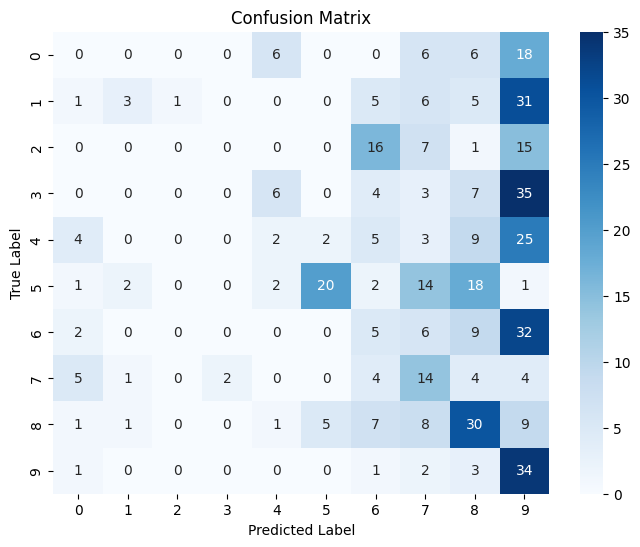

In [20]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
from torch.utils.data import Dataset, DataLoader

# Initialize Model
num_classes = len(np.unique(y_train))
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Initialize Model
model = NN(num_classes).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0001, weight_decay=1e-5)

print("Checking for NaNs in dataset...")
print(f"NaNs in X_train: {np.isnan(X_train).sum()}, NaNs in y_train: {np.isnan(y_train).sum()}")
print(f"Infs in X_train: {np.isinf(X_train).sum()}, Infs in y_train: {np.isinf(y_train).sum()}")


# Training Loop
def train_model(model, train_loader, num_epochs=10):
    model.train()
    for epoch in range(num_epochs):
        running_loss = 0.0
        correct, total = 0, 0
        
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            
            optimizer.zero_grad()
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            correct += (predicted == y_batch).sum().item()
            total += y_batch.size(0)
        
        accuracy = 100 * correct / total
        print(f"Epoch {epoch+1}/{num_epochs}, Loss: {running_loss:.4f}, Accuracy: {accuracy:.2f}%")

# Train Model
train_model(model, train_loader, num_epochs=10)

# Function to evaluate model and display confusion matrix
def evaluate_model(model, test_loader):
    model.eval()
    correct, total = 0, 0
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            outputs = model(X_batch)
            _, predicted = torch.max(outputs, 1)
            
            correct += (predicted == y_batch).sum().item()
            total += y_batch.size(0)
            
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(y_batch.cpu().numpy())
    
    accuracy = 100 * correct / total
    print(f"Test Accuracy: {accuracy:.2f}%")

    # Compute Confusion Matrix
    cm = confusion_matrix(all_labels, all_preds)
    print("\nClassification Report:\n", classification_report(all_labels, all_preds))

    # Plot Confusion Matrix
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=np.unique(y_train), yticklabels=np.unique(y_train))
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title("Confusion Matrix")
    plt.show()

# Test the model and show confusion matrix
evaluate_model(model, test_loader)


Epoch 1/50 - Loss: 236.0591 - Train Acc: 26.37% - Val AUC-ROC: 0.6914
✅ New Best Model Saved! AUC-ROC: 0.6914
Epoch 2/50 - Loss: 181.5519 - Train Acc: 45.80% - Val AUC-ROC: 0.7102
✅ New Best Model Saved! AUC-ROC: 0.7102
Epoch 3/50 - Loss: 156.4667 - Train Acc: 53.75% - Val AUC-ROC: 0.7409
✅ New Best Model Saved! AUC-ROC: 0.7409
Epoch 4/50 - Loss: 127.0057 - Train Acc: 61.75% - Val AUC-ROC: 0.7362
⏳ Early Stopping Counter: 1/5
Epoch 5/50 - Loss: 103.9168 - Train Acc: 69.18% - Val AUC-ROC: 0.7231
⏳ Early Stopping Counter: 2/5
Epoch 6/50 - Loss: 82.0116 - Train Acc: 74.99% - Val AUC-ROC: 0.7246
⏳ Early Stopping Counter: 3/5
Epoch 7/50 - Loss: 63.2395 - Train Acc: 81.97% - Val AUC-ROC: 0.7116
⏳ Early Stopping Counter: 4/5
Epoch 8/50 - Loss: 52.6629 - Train Acc: 84.51% - Val AUC-ROC: 0.6909
⏳ Early Stopping Counter: 5/5
⏹️ Early Stopping Triggered! Best AUC-ROC: 0.7409
🎉 Training Complete!

✅ Test Accuracy: 25.47%
✅ Test AUC-ROC: 0.7022

📊 Macro Avg - Precision: 0.2175, Recall: 0.2390, F1-s

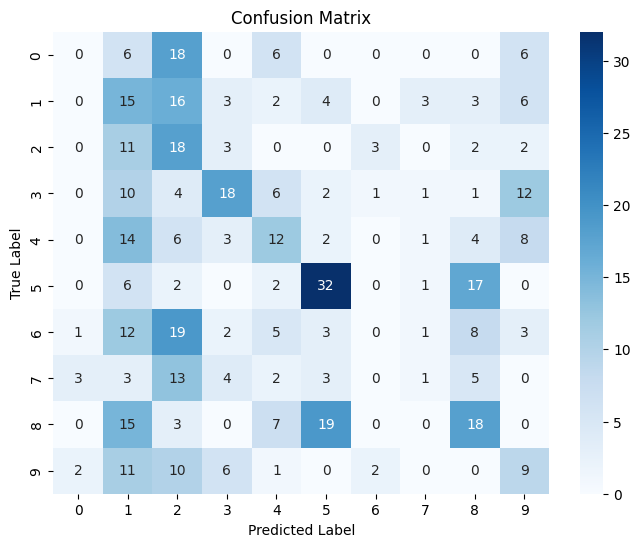

In [21]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score
from torch.utils.data import Dataset, DataLoader

# Model Setup
num_classes = len(np.unique(y_train))
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = NN(num_classes).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0001, weight_decay=1e-5)

# Training with Early Stopping & AUC-ROC Monitoring
def train_model(model, train_loader, val_loader, num_epochs=50, patience=5):
    best_auc_roc = 0.0
    patience_counter = 0
    best_model_path = "best_model.pth"

    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        correct, total = 0, 0

        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)

            optimizer.zero_grad()
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            correct += (predicted == y_batch).sum().item()
            total += y_batch.size(0)

        train_accuracy = 100 * correct / total
        val_auc_roc = evaluate_auc_roc(model, val_loader, num_classes)  # Compute AUC-ROC

        print(f"Epoch {epoch+1}/{num_epochs} - Loss: {running_loss:.4f} - Train Acc: {train_accuracy:.2f}% - Val AUC-ROC: {val_auc_roc:.4f}")

        # Early Stopping Logic
        if val_auc_roc > best_auc_roc:
            best_auc_roc = val_auc_roc
            patience_counter = 0
            torch.save(model.state_dict(), best_model_path)  # Save Best Model
            print(f"✅ New Best Model Saved! AUC-ROC: {best_auc_roc:.4f}")
        else:
            patience_counter += 1
            print(f"⏳ Early Stopping Counter: {patience_counter}/{patience}")

        if patience_counter >= patience:
            print(f"⏹️ Early Stopping Triggered! Best AUC-ROC: {best_auc_roc:.4f}")
            break

    print("🎉 Training Complete!")

from sklearn.preprocessing import label_binarize

from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_auc_score
import numpy as np

def evaluate_auc_roc(model, val_loader, num_classes):
    model.eval()
    all_preds, all_labels = [], []

    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            outputs = model(X_batch)
            probabilities = torch.softmax(outputs, dim=1).cpu().numpy()  # Ensure valid probabilities

            all_preds.extend(probabilities)
            all_labels.extend(y_batch.cpu().numpy())

    all_labels = np.array(all_labels)
    all_preds = np.array(all_preds)

    # 🔍 Debugging NaN values
    if np.isnan(all_preds).sum() > 0 or np.isnan(all_labels).sum() > 0:
        print("⚠️ Warning: NaN values detected in predictions or labels.")
        all_preds = np.nan_to_num(all_preds)  # Replace NaNs with 0
        all_labels = np.nan_to_num(all_labels)

    # Ensure at least two unique classes exist
    if len(set(all_labels)) == 1:
        print("⚠️ Warning: Only one class present in all_labels. AUC-ROC cannot be computed.")
        return 0.0

    # Compute AUC-ROC
    all_labels_bin = label_binarize(all_labels, classes=np.arange(num_classes))

    try:
        if num_classes > 2:
            return roc_auc_score(all_labels_bin, all_preds, multi_class='ovo')
        else:
            return roc_auc_score(all_labels, all_preds[:, 1])  # Binary AUC-ROC
    except ValueError as e:
        print(f"❌ Error in AUC-ROC computation: {e}")
        return 0.0  # Return default value if an error occurs


# Train Model
train_model(model, train_loader, val_loader, num_epochs=50, patience=5)

# Load Best Model and Evaluate on Test Set
best_model = NN(num_classes).to(device)
best_model.load_state_dict(torch.load("best_model.pth"))
best_model.eval()

from sklearn.metrics import precision_recall_fscore_support

from sklearn.preprocessing import label_binarize
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, precision_recall_fscore_support
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch

def evaluate_model(model, test_loader, num_classes):
    model.eval()
    correct, total = 0, 0
    all_preds, all_labels, all_probs = [], [], []

    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            outputs = model(X_batch)

            probabilities = torch.softmax(outputs, dim=1).cpu().numpy()  # Ensure valid probabilities
            _, predicted = torch.max(outputs, 1)  # Predicted class

            correct += (predicted == y_batch).sum().item()
            total += y_batch.size(0)

            all_probs.extend(probabilities)
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(y_batch.cpu().numpy())

    all_labels = np.array(all_labels)
    all_preds = np.array(all_preds)
    all_probs = np.array(all_probs)

    # 🔍 Check for NaN values
    if np.isnan(all_probs).sum() > 0 or np.isnan(all_labels).sum() > 0:
        print("⚠️ Warning: NaN values detected in predictions or labels. Replacing NaNs with zeros.")
        all_probs = np.nan_to_num(all_probs)
        all_labels = np.nan_to_num(all_labels)

    # 🔍 Ensure at least two unique classes exist
    if len(set(all_labels)) == 1:
        print("⚠️ Warning: Only one class present in all_labels. AUC-ROC and multi-class metrics cannot be computed.")
        auc_roc = 0.0
    else:
        # Compute AUC-ROC
        all_labels_bin = label_binarize(all_labels, classes=np.arange(num_classes))
        try:
            if num_classes > 2:
                auc_roc = roc_auc_score(all_labels_bin, all_probs, multi_class='ovo')
            else:
                auc_roc = roc_auc_score(all_labels, all_probs[:, 1])  # Binary AUC-ROC
        except ValueError as e:
            print(f"❌ Error in AUC-ROC computation: {e}")
            auc_roc = 0.0

    # Compute Accuracy
    accuracy = 100 * correct / total if total > 0 else 0.0

    # Compute Precision, Recall, F1-score for each class
    try:
        precision, recall, f1, _ = precision_recall_fscore_support(all_labels, all_preds, average=None, zero_division=0)
        macro_precision, macro_recall, macro_f1, _ = precision_recall_fscore_support(all_labels, all_preds, average='macro', zero_division=0)
        weighted_precision, weighted_recall, weighted_f1, _ = precision_recall_fscore_support(all_labels, all_preds, average='weighted', zero_division=0)
    except ValueError as e:
        print(f"❌ Error in Precision/Recall/F1 computation: {e}")
        precision, recall, f1 = [0] * num_classes, [0] * num_classes, [0] * num_classes
        macro_precision, macro_recall, macro_f1 = 0.0, 0.0, 0.0
        weighted_precision, weighted_recall, weighted_f1 = 0.0, 0.0, 0.0

    # Print evaluation results
    print(f"\n✅ Test Accuracy: {accuracy:.2f}%")
    print(f"✅ Test AUC-ROC: {auc_roc:.4f}\n")

    print(f"📊 Macro Avg - Precision: {macro_precision:.4f}, Recall: {macro_recall:.4f}, F1-score: {macro_f1:.4f}")
    print(f"📊 Weighted Avg - Precision: {weighted_precision:.4f}, Recall: {weighted_recall:.4f}, F1-score: {weighted_f1:.4f}")

    # Display Per-Class Metrics
    for i in range(num_classes):
        print(f"🔹 Class {i} - Precision: {precision[i]:.4f}, Recall: {recall[i]:.4f}, F1-score: {f1[i]:.4f}")

    # Compute Confusion Matrix
    cm = confusion_matrix(all_labels, all_preds)

    print("\n📌 Classification Report:\n", classification_report(all_labels, all_preds, digits=4))

    # Plot Confusion Matrix
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=np.arange(num_classes), yticklabels=np.arange(num_classes))
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title("Confusion Matrix")
    plt.show()


# Evaluate Best Model
evaluate_model(best_model, test_loader, num_classes)


# Dummy Pipeline

In [ ]:
# stop_execution()

In [ ]:
class DummyPipeline:

    d = None
    
    x_diff = None
    y_diff = None

    x_mask = None
    y_mask = None
    mask= None

    saccade_signals = None
    saccade_gen = None
    saccade_seq = None
    
    
    def __init__(self, t, x, y, x_left, y_left):
        self.t = t
        self.x = x
        self.y = y
        self.x_left = x_left
        self.y_left = y_left

    def run(self):
        
        (
        self.t,
        self.x,
        self.y,
        self.x_left,
        self.y_left
        ) = self.__drop_nans_with_context(self.t, self.x, self.y, self.x_left, self.y_left, context_size=5)
        
        self.t = self.__normalization_min_max_positive(self.t)
        self.x = self.__normalization_min_max_positive(self.x)
        self.y = self.__normalization_min_max_positive(self.y)
        self.x_left = self.__normalization_min_max_positive(self.x_left)
        self.y_left = self.__normalization_min_max_positive(self.y_left)

        self.mask = self.__generate_peaks(self.x, 100)

        x_saccade = self.__extract_peak_segments(self.x, self.mask, context_size=CONTEXT)
        y_saccade = self.__extract_peak_segments(self.y, self.mask, context_size=CONTEXT)
        x_left_saccade = self.__extract_peak_segments(self.x_left, self.mask, context_size=CONTEXT)
        y_left_saccade = self.__extract_peak_segments(self.y_left, self.mask, context_size=CONTEXT)
        
        return x_saccade, x_saccade, x_saccade, x_left_saccade, x_left_saccade, x_left_saccade 

    def __drop_nans_with_context(self, *signals, context_size=10):
        assert len(signals) > 0, "At least one signal must be provided."
    
        signals = [pd.Series(sig).reset_index(drop=True) if not isinstance(sig, pd.Series) else sig.reset_index(drop=True) for sig in signals]
        nan_indices = np.unique(np.concatenate([
            sig[sig.isna() | (sig == "nan")].index for sig in signals
        ]))
    
        if len(nan_indices) == 0:
            return signals

        expanded_indices = np.unique(np.concatenate([
            np.arange(max(0, idx - context_size), min(len(signals[0]), idx + context_size + 1))
            for idx in nan_indices
        ]))
    
        filtered_signals = [sig.drop(expanded_indices).reset_index(drop=True) for sig in signals]
    
        filtered_signals = [sig.dropna().reset_index(drop=True) for sig in filtered_signals]
    
        min_length = min(map(len, filtered_signals))
        filtered_signals = [sig.iloc[:min_length].reset_index(drop=True) for sig in filtered_signals]
    
        return tuple(filtered_signals)

    def __normalization_min_max_positive(self, signal):
        return (signal - signal.min()) / (signal.max() - signal.min())
        
    def __extract_peak_segments(self, signal, mask, context_size=5):
        signal = np.array(signal)
        mask = np.array(mask)
    
        assert len(signal) == len(mask), "Signal and mask must have the same length."
    
        extracted_segments = []
        peak_indices = np.where(mask == 1)[0]
    
        for idx in peak_indices:
            start = max(0, idx - context_size)
            end = min(len(signal), idx + context_size + 1)
            
            extracted_segments.append(signal[start:end])
        return extracted_segments
    
    def __generate_peaks(self, signal, num_of_peaks):
        signal_length = len(signal)
        
        # Ensure num_of_peaks is not greater than the signal length
        num_of_peaks = min(num_of_peaks, signal_length)
        
        # Create an array of zeros
        new_signal = np.zeros(signal_length, dtype=int)
        
        # Randomly choose indices to place ones
        peak_indices = np.random.choice(signal_length, num_of_peaks, replace=False)
        
        # Assign ones at the selected indices
        new_signal[peak_indices] = 1
        
        return new_signal




In [ ]:
file_path = "../data/00/data.csv"
df = pd.read_csv(file_path)

selected_columns = ["t", "right_gaze_origin_position_in_hmd_coordinates_x", "right_gaze_origin_position_in_hmd_coordinates_y",
                    "left_gaze_origin_position_in_hmd_coordinates_x", "left_gaze_origin_position_in_hmd_coordinates_y"]
df = df[selected_columns]

df = df.rename(columns={
    "right_gaze_origin_position_in_hmd_coordinates_x": "x",
    "right_gaze_origin_position_in_hmd_coordinates_y": "y",
    "left_gaze_origin_position_in_hmd_coordinates_x": "x_left",
    "left_gaze_origin_position_in_hmd_coordinates_y": "y_left"
})

pipeline = DummyPipeline(df["t"], df["x"], df["y"], df["x_left"], df["y_left"])
saccade_signals = pipeline.run()

num_features = len(saccade_signals)

fig, axes = plt.subplots(1, 1, figsize=(8, 8), sharex=True)

for signal in saccade_signals[3][:10]:
    axes.plot(signal, marker='o', linestyle='-', markersize=2, alpha=0.7)
axes.set_ylabel("Rigth Eye")
axes.set_title("Distance vs Time")
axes.grid(True)

In [ ]:
def generate_features(df):
    generated_signals = []
    generated_labels = []
    
    # Iterate over unique labels
    for label in df["label"].unique():
        df_label = df[df["label"] == label]
    
        # Iterate over unique segments
        for segment in df_label["segment"].unique():
            df_segment = df_label[df_label["segment"] == segment]
    
            # Extract input signals for the pipeline based on signal_type
            t = df_segment[df_segment["signal_type"] == "t"].drop(columns=["label", "signal_type", "segment"]).values.flatten()
            x = df_segment[df_segment["signal_type"] == "x"].drop(columns=["label", "signal_type", "segment"]).values.flatten()
            y = df_segment[df_segment["signal_type"] == "y"].drop(columns=["label", "signal_type", "segment"]).values.flatten()
            x_left = df_segment[df_segment["signal_type"] == "x_left"].drop(columns=["label", "signal_type", "segment"]).values.flatten()
            y_left = df_segment[df_segment["signal_type"] == "y_left"].drop(columns=["label", "signal_type", "segment"]).values.flatten()
    
            # Run the pipeline 10 times for each segment
            # for _ in range(10):
            pipeline = DummyPipeline(t, x, y, x_left, y_left)
            results = pipeline.run()
            
            # Store the generated signal and label
            for result in results:
                valid_result = [signal for signal in result if len(signal) == 2 * CONTEXT + 1]
                generated_signals.extend(valid_result)
                generated_labels.extend([label]*len(valid_result))
    
    # Convert results into DataFrame
    return pd.DataFrame(generated_signals), pd.DataFrame({"label": generated_labels})

df_train, df_train_labels = generate_features(df_train_raw)
# df_train = df_train.iloc[:, :1000]

df_test, df_test_labels = generate_features(df_test_raw)
# df_test = df_test.iloc[:, :1000]

df_val, df_val_labels = generate_features(df_val_raw)
# df_val = df_val.iloc[:, :1000]

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
from torch.utils.data import Dataset, DataLoader

# Initialize Model
num_classes = len(np.unique(y_train))
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Initialize Model
model = NN(num_classes).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0001, weight_decay=1e-5)


# Training Loop
def train_model(model, train_loader, num_epochs=10):
    model.train()
    for epoch in range(num_epochs):
        running_loss = 0.0
        correct, total = 0, 0
        
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            
            optimizer.zero_grad()
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            correct += (predicted == y_batch).sum().item()
            total += y_batch.size(0)
        
        accuracy = 100 * correct / total
        print(f"Epoch {epoch+1}/{num_epochs}, Loss: {running_loss:.4f}, Accuracy: {accuracy:.2f}%")

# Train Model
train_model(model, train_loader, num_epochs=10)

# Function to evaluate model and display confusion matrix
def evaluate_model(model, test_loader):
    model.eval()
    correct, total = 0, 0
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            outputs = model(X_batch)
            _, predicted = torch.max(outputs, 1)
            
            correct += (predicted == y_batch).sum().item()
            total += y_batch.size(0)
            
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(y_batch.cpu().numpy())
    
    accuracy = 100 * correct / total
    print(f"Test Accuracy: {accuracy:.2f}%")

    # Compute Confusion Matrix
    cm = confusion_matrix(all_labels, all_preds)
    print("\nClassification Report:\n", classification_report(all_labels, all_preds))

    # Plot Confusion Matrix
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=np.unique(y_train), yticklabels=np.unique(y_train))
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title("Confusion Matrix")
    plt.show()

# Test the model and show confusion matrix
evaluate_model(model, test_loader)
